# Phase 2 — Exploratory Data Analysis

This notebook performs the EDA required for the Heart Disease ML project.

The goal is to inspect the Cleveland training site and compare it against the Hungarian and Swiss external sites, because the project treats Cleveland → Hungarian/Swiss as a distribution shift problem.

This notebook is intentionally **read-only**: it displays plots and tables inline but does **not** save CSV files, figures, models, or other external outputs. Saved outputs should be generated later by the corresponding Python module/runner.

## Plan

We will check the main issues reviewers usually expect in medical ML EDA: class balance, missing data, feature distributions, correlations, and cross-site distribution shift. The last part is especially important because domain adaptation is one of the required project contributions.

In [12]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/aexomir/Desktop/AIMed


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import missingno as msno
    HAS_MISSINGNO = True
except ImportError:
    HAS_MISSINGNO = False
    print("missingno is not installed. Install it with: pip install missingno")

from scipy import stats

## Check — Load Phase 1 data

Phase 2 depends on Phase 1. We first load the three site-specific datasets using the Phase 1 data module.

In [14]:
# Try the recommended import first.
# If your file is named src/01-dataset.py, Python cannot import it normally because of the dash.
# In that case, this fallback loads the file directly from its path.
try:
    from src.data import run_dataset_setup
except Exception:
    import importlib.util
    data_module_path = PROJECT_ROOT / "src" / "01-dataset.py"
    spec = importlib.util.spec_from_file_location("phase1_dataset", data_module_path)
    phase1_dataset = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(phase1_dataset)
    run_dataset_setup = phase1_dataset.run_dataset_setup

datasets = run_dataset_setup()

cleveland = datasets["cleveland"].copy()
hungarian = datasets["hungarian"].copy()
swiss = datasets["swiss"].copy()

print("Loaded datasets:")
print("Cleveland:", cleveland.shape)
print("Hungarian:", hungarian.shape)
print("Swiss:", swiss.shape)


Phase 1 — Dataset setup
Loading Cleveland, Hungarian, and Swiss UCI Heart Disease splits...
Found local file for cleveland: /Users/aexomir/Desktop/AIMed/data/raw/processed.cleveland.data
Found local file for hungarian: /Users/aexomir/Desktop/AIMed/data/raw/processed.hungarian.data
Found local file for swiss: /Users/aexomir/Desktop/AIMed/data/raw/processed.switzerland.data
Column alignment check passed for Cleveland, Hungarian, and Swiss.

CLEVELAND
Shape: 303 rows × 16 columns

Binary label distribution:
target
0    164
1    139
Positive disease rate: 45.87%

Original target values before binary collapse:
target_original
0    164
1     55
2     36
3     35
4     13

Missing values in modeling columns:
ca      4
thal    2

HUNGARIAN
Shape: 294 rows × 16 columns

Binary label distribution:
target
0    188
1    106
Positive disease rate: 36.05%

Original target values before binary collapse:
target_original
0    188
1    106

Missing values in modeling columns:
trestbps      1
chol      

## Standardize data types for EDA

The original UCI files may contain missing values encoded as `?`, which can make numeric columns appear as string/object columns. Before computing means, statistical tests, and histograms, we convert all feature columns to numeric with invalid values coerced to `NaN`.

In [15]:
TARGET_COL = "target" if "target" in cleveland.columns else "num"
FEATURE_COLS = [col for col in cleveland.columns if col != TARGET_COL]

site_dfs = {
    "Cleveland": cleveland,
    "Hungarian": hungarian,
    "Swiss": swiss,
}

for name, df in site_dfs.items():
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").astype("Int64")
    for col in FEATURE_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Target column:", TARGET_COL)
print("Number of feature columns:", len(FEATURE_COLS))
print("Feature columns:", FEATURE_COLS)

Target column: target
Number of feature columns: 15
Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'site', 'target_original']


## Execute — Class balance

We inspect the positive/negative label distribution in each split. This helps decide whether resampling or threshold-aware metrics are needed.

In [16]:
class_balance_rows = []

for name, df in site_dfs.items():
    counts = df[TARGET_COL].value_counts(dropna=False).sort_index()
    n = len(df)
    negatives = int(counts.get(0, 0))
    positives = int(counts.get(1, 0))
    positive_rate = positives / n if n else np.nan
    class_balance_rows.append({
        "site": name,
        "n_rows": n,
        "negative_0": negatives,
        "positive_1": positives,
        "positive_rate": positive_rate,
    })

class_balance = pd.DataFrame(class_balance_rows)
class_balance

,site,n_rows,negative_0,positive_1,positive_rate
0,Cleveland,303,164,139,0.458746
1,Hungarian,294,188,106,0.360544
2,Swiss,123,8,115,0.934959


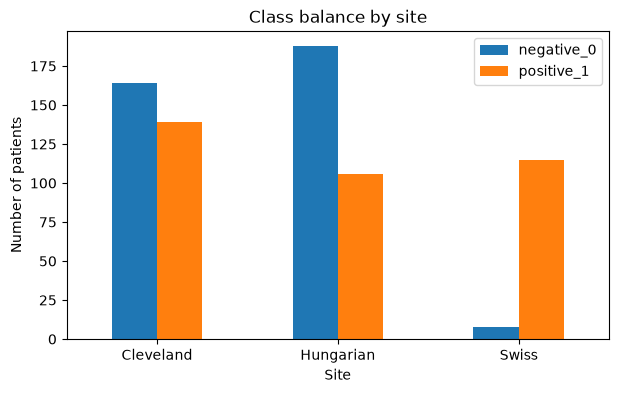

In [17]:
ax = class_balance.set_index("site")[["negative_0", "positive_1"]].plot(kind="bar", figsize=(7, 4))
ax.set_title("Class balance by site")
ax.set_xlabel("Site")
ax.set_ylabel("Number of patients")
plt.xticks(rotation=0)
plt.show()

## Execute — Missingness summary

Missingness matters clinically because missing values may correspond to unavailable tests, different hospital protocols, or measurement limitations. These patterns directly motivate imputation in the preprocessing pipeline.

In [18]:
missingness_tables = []

for name, df in site_dfs.items():
    miss = df.isna().mean().rename("missing_rate").reset_index().rename(columns={"index": "feature"})
    miss["site"] = name
    missingness_tables.append(miss)

missingness_summary = pd.concat(missingness_tables, ignore_index=True)
missingness_pivot = missingness_summary.pivot(index="feature", columns="site", values="missing_rate")
missingness_pivot.sort_values("Cleveland", ascending=False).style.format("{:.1%}")

site,Cleveland,Hungarian,Swiss
feature,,,
site,100.0%,100.0%,100.0%
ca,1.3%,99.0%,95.9%
thal,0.7%,90.5%,42.3%
age,0.0%,0.0%,0.0%
chol,0.0%,7.8%,0.0%
cp,0.0%,0.0%,0.0%
exang,0.0%,0.3%,0.8%
fbs,0.0%,2.7%,61.0%
oldpeak,0.0%,0.0%,4.9%


Missingness heatmap: Cleveland


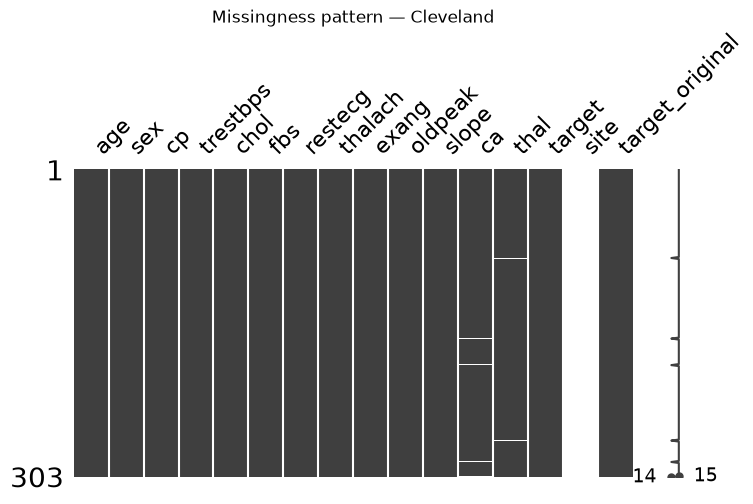

Missingness heatmap: Hungarian


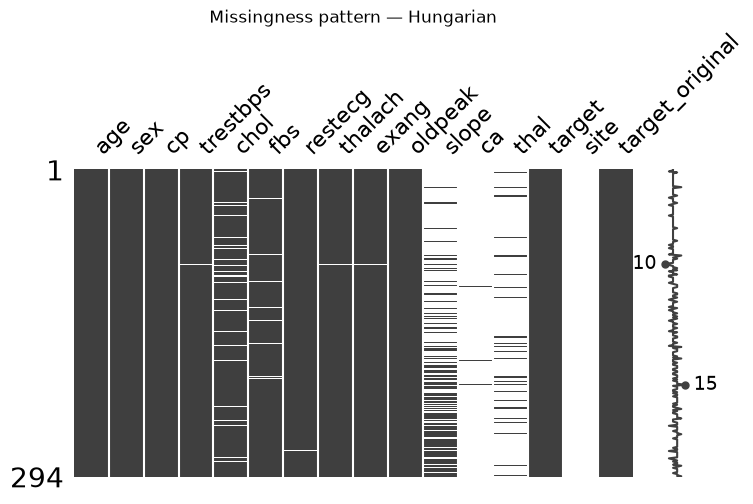

Missingness heatmap: Swiss


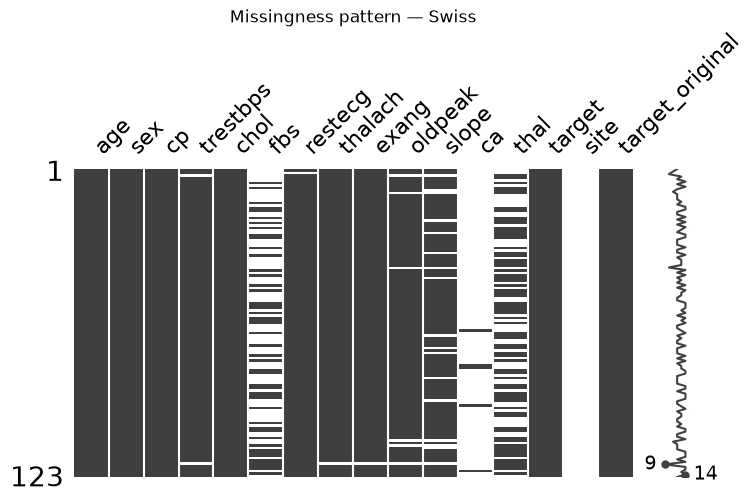

In [19]:
for name, df in site_dfs.items():
    print(f"Missingness heatmap: {name}")
    if HAS_MISSINGNO:
        msno.matrix(df, figsize=(8, 4))
        plt.title(f"Missingness pattern — {name}")
        plt.show()
    else:
        plt.figure(figsize=(8, 3))
        plt.imshow(df.isna(), aspect="auto")
        plt.title(f"Missingness pattern — {name}")
        plt.xlabel("Columns")
        plt.ylabel("Rows")
        plt.show()

## Execute — Cleveland feature distributions by label

These histograms show how each feature behaves inside the Cleveland training site, split by disease label. Since Cleveland is the only training source, this is the distribution the models will learn from.

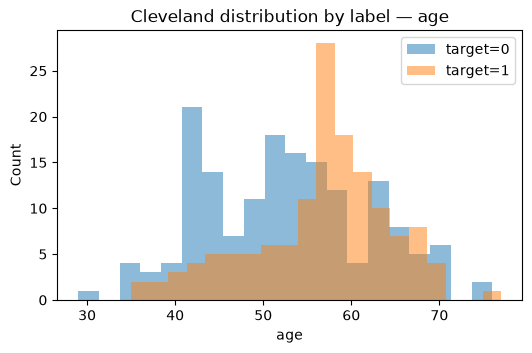

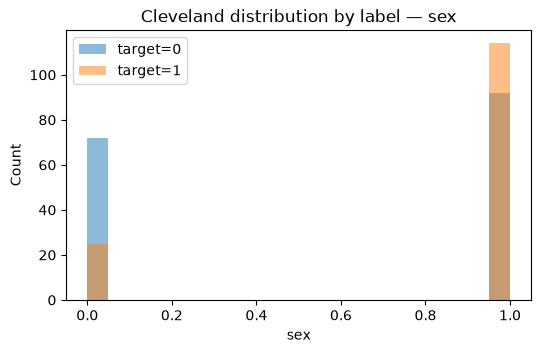

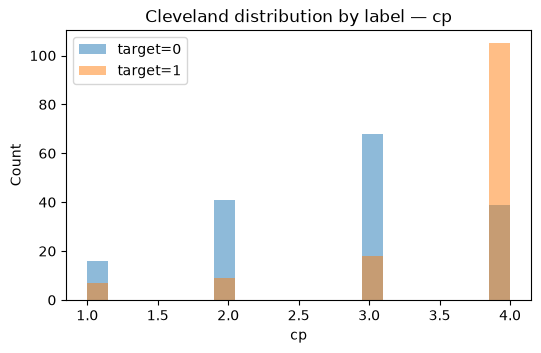

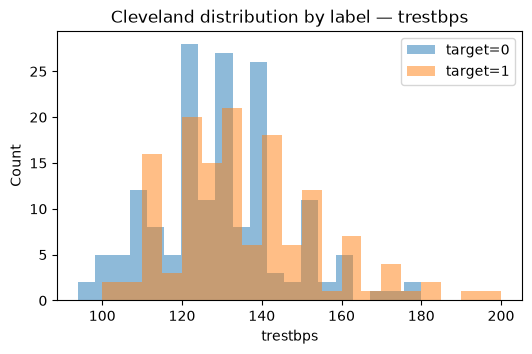

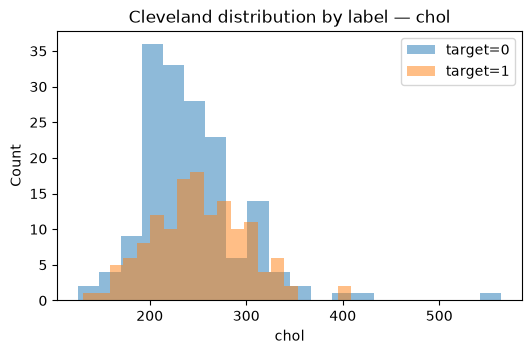

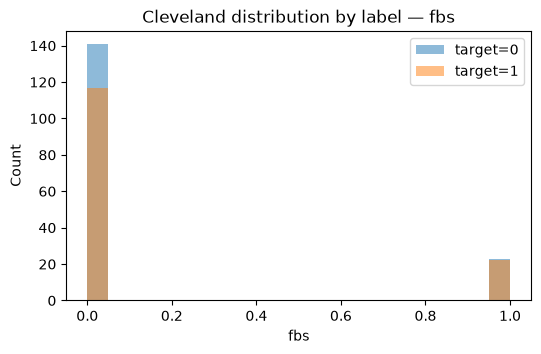

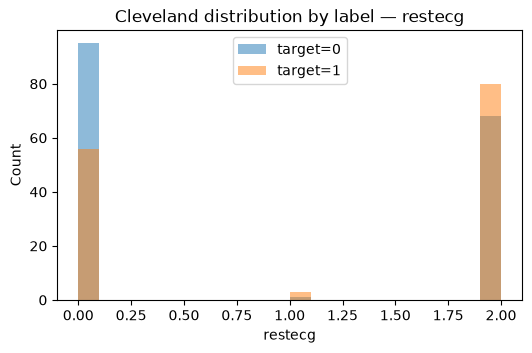

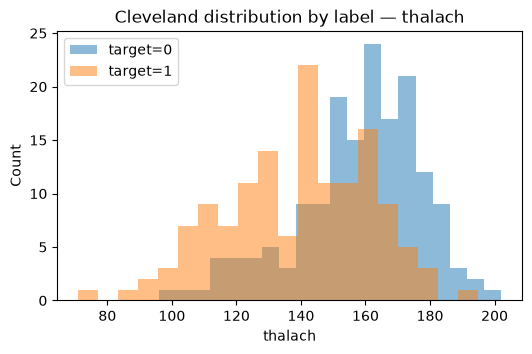

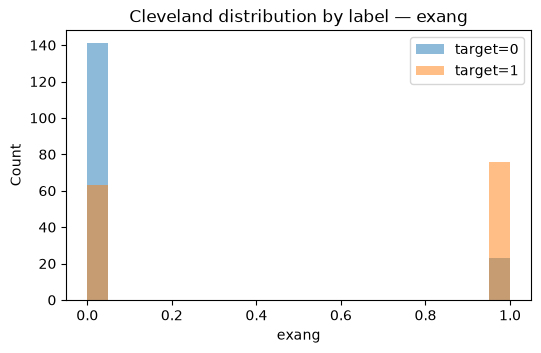

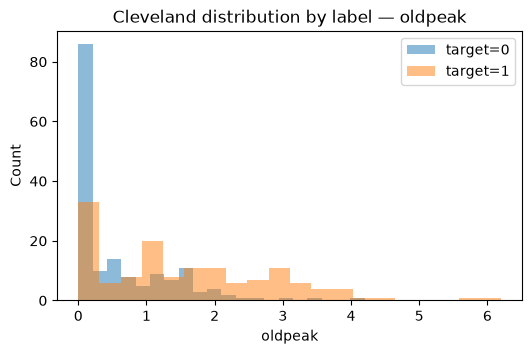

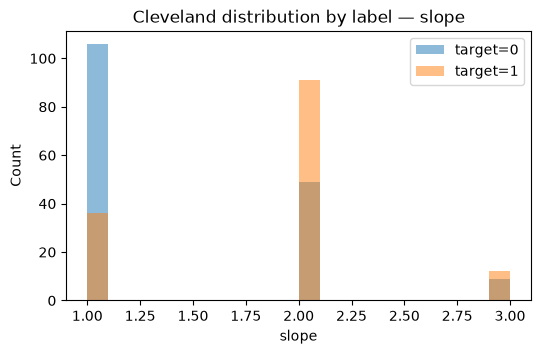

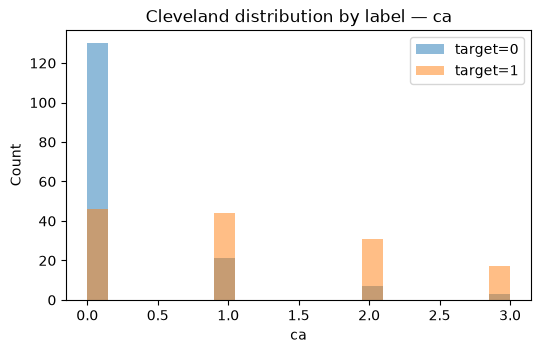

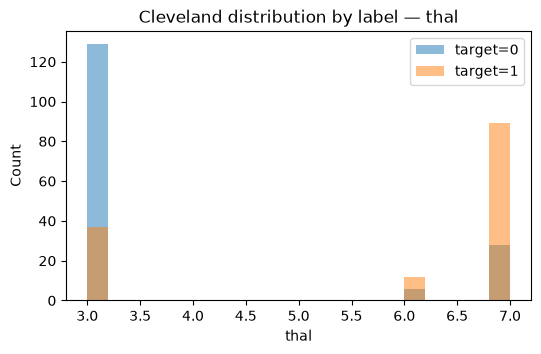

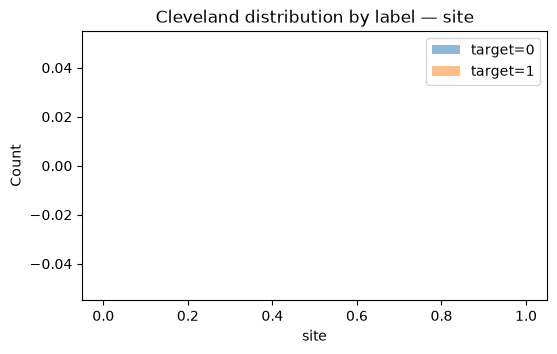

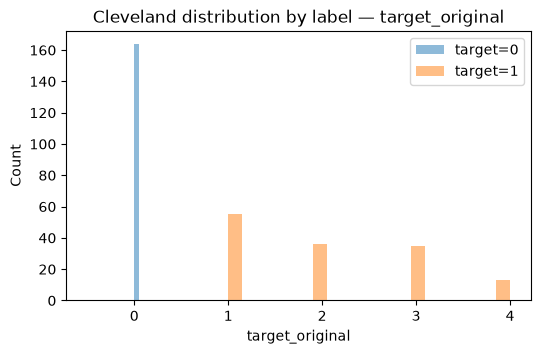

In [20]:
for feature in FEATURE_COLS:
    plt.figure(figsize=(6, 3.5))
    for label in sorted(cleveland[TARGET_COL].dropna().unique()):
        values = cleveland.loc[cleveland[TARGET_COL] == label, feature].dropna()
        plt.hist(values, bins=20, alpha=0.5, label=f"target={label}")
    plt.title(f"Cleveland distribution by label — {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

## Execute — Cleveland correlation matrix

The correlation matrix is computed only on Cleveland to avoid using external test data during modeling decisions. It helps identify redundant variables and possible interaction effects for Phase 3.

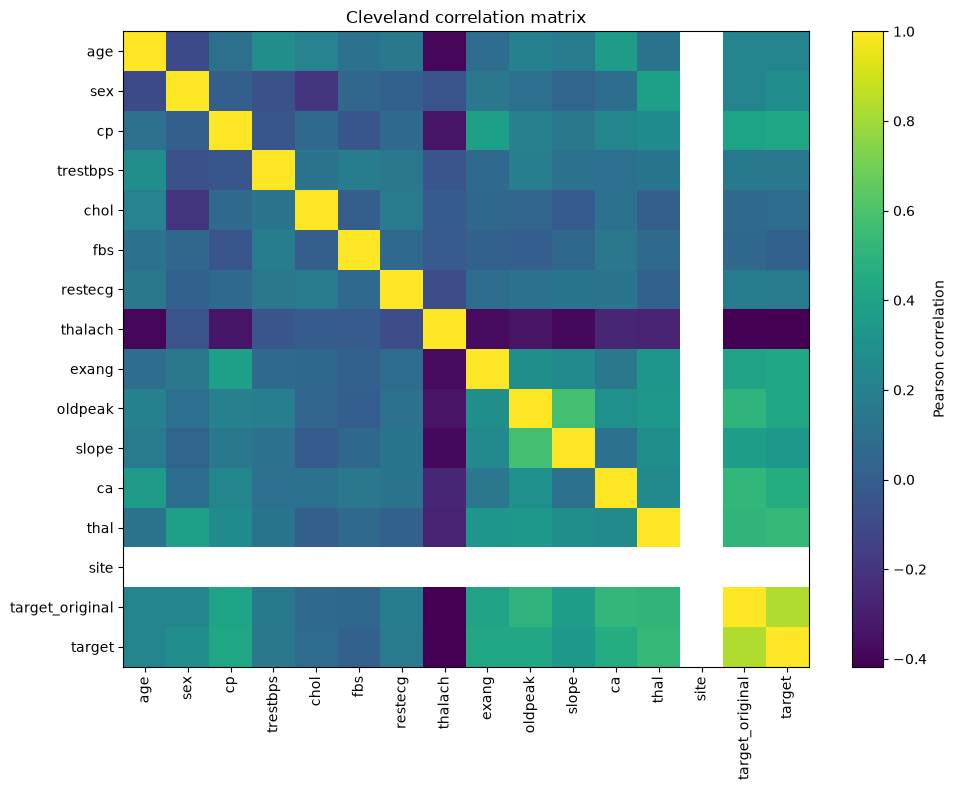

target             1.000000
target_original    0.830081
thal               0.525689
ca                 0.460442
exang              0.431894
oldpeak            0.424510
cp                 0.414446
slope              0.339213
sex                0.276816
age                0.223120
restecg            0.169202
trestbps           0.150825
chol               0.085164
fbs                0.025264
thalach           -0.417167
site                    NaN
Name: target, dtype: float64

In [21]:
cleveland_corr = cleveland[FEATURE_COLS + [TARGET_COL]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(cleveland_corr, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(cleveland_corr.columns)), cleveland_corr.columns, rotation=90)
plt.yticks(range(len(cleveland_corr.index)), cleveland_corr.index)
plt.title("Cleveland correlation matrix")
plt.tight_layout()
plt.show()

cleveland_corr[TARGET_COL].sort_values(ascending=False)

## Execute — Cross-site distribution shift table

This table compares Cleveland against Hungarian and Swiss feature-by-feature. Continuous-like features use the Kolmogorov-Smirnov test. Discrete/categorical-like features use the Mann-Whitney U test as a simple non-parametric comparison.

The goal is not to make final clinical claims from p-values, but to identify which features shift most across hospitals and may be hardest for a model trained only on Cleveland to generalize.

In [22]:
def is_discrete_like(series, max_unique=10):
    values = pd.to_numeric(series, errors="coerce").dropna()
    return values.nunique() <= max_unique


def compare_feature_shift(source, target, feature):
    a = pd.to_numeric(source[feature], errors="coerce").dropna()
    b = pd.to_numeric(target[feature], errors="coerce").dropna()

    if len(a) == 0 or len(b) == 0:
        return {
            "test": "not_enough_data",
            "statistic": np.nan,
            "p_value": np.nan,
            "source_mean": np.nan,
            "target_mean": np.nan,
            "mean_delta": np.nan,
            "source_missing_rate": source[feature].isna().mean(),
            "target_missing_rate": target[feature].isna().mean(),
        }

    if is_discrete_like(a) or is_discrete_like(b):
        test = "mann_whitney_u"
        try:
            stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        except ValueError:
            stat, p = np.nan, np.nan
    else:
        test = "ks_2sample"
        stat, p = stats.ks_2samp(a, b)

    return {
        "test": test,
        "statistic": stat,
        "p_value": p,
        "source_mean": a.mean(),
        "target_mean": b.mean(),
        "mean_delta": b.mean() - a.mean(),
        "source_missing_rate": source[feature].isna().mean(),
        "target_missing_rate": target[feature].isna().mean(),
    }


shift_rows = []
for external_name, external_df in {"Hungarian": hungarian, "Swiss": swiss}.items():
    for feature in FEATURE_COLS:
        result = compare_feature_shift(cleveland, external_df, feature)
        shift_rows.append({
            "comparison": f"Cleveland_vs_{external_name}",
            "feature": feature,
            **result,
        })

shift_table = pd.DataFrame(shift_rows)
shift_table["abs_mean_delta"] = shift_table["mean_delta"].abs()
shift_table["missing_rate_delta"] = (shift_table["target_missing_rate"] - shift_table["source_missing_rate"]).abs()

shift_table_sorted = shift_table.sort_values(
    by=["p_value", "abs_mean_delta", "missing_rate_delta"],
    ascending=[True, False, False],
    na_position="last",
)

shift_table_sorted.style.format({
    "statistic": "{:.4f}",
    "p_value": "{:.3e}",
    "source_mean": "{:.3f}",
    "target_mean": "{:.3f}",
    "mean_delta": "{:.3f}",
    "abs_mean_delta": "{:.3f}",
    "source_missing_rate": "{:.1%}",
    "target_missing_rate": "{:.1%}",
    "missing_rate_delta": "{:.1%}",
})

,comparison,feature,test,statistic,p_value,source_mean,target_mean,mean_delta,source_missing_rate,target_missing_rate,abs_mean_delta,missing_rate_delta
19,Cleveland_vs_Swiss,chol,mann_whitney_u,37269.0000,2.670e-60,246.693,0.000,-246.693,0.0%,0.0%,246.693,0.0%
6,Cleveland_vs_Hungarian,restecg,mann_whitney_u,61706.5000,1.415e-22,0.990,0.218,-0.772,0.0%,0.3%,0.772,0.3%
22,Cleveland_vs_Swiss,thalach,ks_2sample,0.4642,1.582e-17,149.607,121.557,-28.050,0.0%,0.8%,28.050,0.8%
0,Cleveland_vs_Hungarian,age,ks_2sample,0.3554,2.816e-17,54.439,47.827,-6.612,0.0%,0.0%,6.612,0.0%
29,Cleveland_vs_Swiss,target_original,mann_whitney_u,10179.5000,1.516e-14,0.937,1.805,0.868,0.0%,0.0%,0.868,0.0%
9,Cleveland_vs_Hungarian,oldpeak,mann_whitney_u,57146.5000,2.098e-10,1.040,0.586,-0.454,0.0%,0.0%,0.454,0.0%
17,Cleveland_vs_Swiss,cp,mann_whitney_u,12421.0000,1.629e-09,3.158,3.699,0.541,0.0%,0.0%,0.541,0.0%
7,Cleveland_vs_Hungarian,thalach,ks_2sample,0.2614,1.850e-09,149.607,139.130,-10.478,0.0%,0.3%,10.478,0.3%
21,Cleveland_vs_Swiss,restecg,mann_whitney_u,24355.5000,6.442e-09,0.990,0.361,-0.629,0.0%,0.8%,0.629,0.8%
10,Cleveland_vs_Hungarian,slope,mann_whitney_u,11075.5000,2.259e-07,1.601,1.894,0.294,0.0%,64.6%,0.294,64.6%


## Evaluate — Features with strongest apparent shift

The table below lists the most shifted features per external site. These are the variables that should be discussed in Phase 3 when motivating imputation, feature engineering, and domain adaptation.

In [23]:
for comparison in shift_table_sorted["comparison"].unique():
    print("" + "=" * 80)
    print(comparison)
    print("=" * 80)
    display(
        shift_table_sorted
        .query("comparison == @comparison")
        .head(8)[[
            "feature",
            "test",
            "p_value",
            "source_mean",
            "target_mean",
            "mean_delta",
            "source_missing_rate",
            "target_missing_rate",
        ]]
    )

Cleveland_vs_Swiss


,feature,test,p_value,source_mean,target_mean,mean_delta,source_missing_rate,target_missing_rate
19,chol,mann_whitney_u,2.670263e-60,246.693069,0.000000,-246.693069,0.000000,0.000000
22,thalach,ks_2sample,1.581912e-17,149.607261,121.557377,-28.049884,0.000000,0.008130
29,target_original,mann_whitney_u,1.516329e-14,0.937294,1.804878,0.867584,0.000000,0.000000
17,cp,mann_whitney_u,1.629402e-09,3.158416,3.699187,0.540771,0.000000,0.000000
21,restecg,mann_whitney_u,6.442344e-09,0.990099,0.360656,-0.629443,0.000000,0.008130
16,sex,mann_whitney_u,2.685695e-07,0.679868,0.918699,0.238831,0.000000,0.000000
27,thal,mann_whitney_u,1.043544e-04,4.734219,5.788732,1.054513,0.006601,0.422764
25,slope,mann_whitney_u,3.679285e-03,1.600660,1.801887,0.201227,0.000000,0.138211


Cleveland_vs_Hungarian


,feature,test,p_value,source_mean,target_mean,mean_delta,source_missing_rate,target_missing_rate
6,restecg,mann_whitney_u,1.415478e-22,0.990099,0.218430,-0.771669,0.0,0.003401
0,age,ks_2sample,2.816493e-17,54.438944,47.826531,-6.612413,0.0,0.000000
9,oldpeak,mann_whitney_u,2.097898e-10,1.039604,0.586054,-0.453550,0.0,0.000000
7,thalach,ks_2sample,1.850007e-09,149.607261,139.129693,-10.477568,0.0,0.003401
10,slope,mann_whitney_u,2.258719e-07,1.600660,1.894231,0.293571,0.0,0.646259
14,target_original,mann_whitney_u,1.953667e-06,0.937294,0.360544,-0.576750,0.0,0.000000
5,fbs,mann_whitney_u,2.372841e-03,0.148515,0.069930,-0.078585,0.0,0.027211
2,cp,mann_whitney_u,1.864044e-02,3.158416,2.982993,-0.175423,0.0,0.000000


## Markdown notes to fill after running

After running the notebook, summarize the actual findings here.

Suggested structure:

1. **Class balance** — State whether Cleveland is sufficiently balanced for training and whether Hungarian/Swiss have different positive rates.
2. **Missingness** — Name the features with the highest missingness and explain that imputation must be fitted only on Cleveland train.
3. **Feature distributions** — Mention clinically meaningful differences seen in Cleveland by label.
4. **Cross-site shift** — List the features with strongest Cleveland → Hungarian and Cleveland → Swiss shifts.
5. **Phase 3 implications** — Explain why the modeling phase needs a shared preprocessing pipeline, external validation, calibration, and an ablatable domain adaptation module.

## Phase 3 decisions informed by EDA

This EDA should directly inform the modeling phase:

- Features with missing values require an imputer fitted only on Cleveland train.
- If the class balance is not severely skewed, resampling is probably unnecessary; use AUC-ROC, AUC-PR, F1, sensitivity, and specificity instead.
- Features with strong cross-site shift are likely to be difficult for external generalization.
- Domain adaptation should be isolated and ablatable so that Phase 4 can quantify with-vs-without performance changes.